### House Prices EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/house_prices/train.csv', index_col='Id')
test_df = pd.read_csv('data/house_prices/test.csv', index_col='Id')
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

#### Категориальные и числовые фичи

In [4]:
df.dtypes.value_counts()

str        43
int64      34
float64     3
Name: count, dtype: int64

In [5]:
numerical_feats = df.dtypes[df.dtypes != "str"].index
categorical_feats = df.dtypes[df.dtypes == "str"].index

print(f"{len(numerical_feats)=}, {len(categorical_feats)=}")

len(numerical_feats)=37, len(categorical_feats)=43


#### Посмотрим N/A значения

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(inplace=True)
missing

Electrical         1
MasVnrArea         8
BsmtCond          37
BsmtFinType1      37
BsmtQual          37
BsmtExposure      38
BsmtFinType2      38
GarageType        81
GarageQual        81
GarageFinish      81
GarageCond        81
GarageYrBlt       81
LotFrontage      259
FireplaceQu      690
MasVnrType       872
Fence           1179
Alley           1369
MiscFeature     1406
PoolQC          1453
dtype: int64

Или в процентах: 4 фичи имеют 80%+ пропущенных значений

<Axes: >

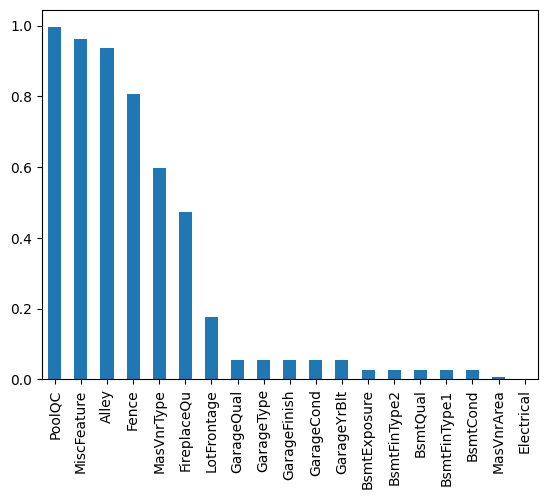

In [7]:
percent = (df.isnull().sum() / df.isnull().count()).sort_values(ascending=False)
percent[percent > 0].plot.bar()

Если почитать описание данных, можно увидеть, что для некоторых категориальных фич N/A означает отсутствие, что само по себе несет информацию

In [8]:
cols_fillna = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "MasVnrType",
    "FireplaceQu",
    "GarageQual",
    "GarageCond",
    "GarageFinish",
    "GarageType",
    "Electrical",
    "KitchenQual",
    "SaleType",
    "Functional",
    "Exterior2nd",
    "Exterior1st",
    "BsmtExposure",
    "BsmtCond",
    "BsmtQual",
    "BsmtFinType1",
    "BsmtFinType2",
    "MSZoning",
    "Utilities",
]

for col in cols_fillna:
    df[col] = df[col].fillna("None")

percent = (df.isnull().sum() / df.isnull().count()).sort_values(ascending=False)
percent

LotFrontage      0.177397
GarageYrBlt      0.055479
MasVnrArea       0.005479
MSSubClass       0.000000
Street           0.000000
                   ...   
MoSold           0.000000
YrSold           0.000000
SaleType         0.000000
SaleCondition    0.000000
SalePrice        0.000000
Length: 80, dtype: float64

In [9]:
[
    "LotFrontage" in numerical_feats,
    "GarageYrBlt" in numerical_feats,
    "MasVnrArea" in numerical_feats,
]

[True, True, True]

In [10]:
numerical_feats

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='str')

Остальные фичи с N/A - числовые, их можно заменить средним, но уже после сплита на трейн и тест

#### Таргет 

распределение не нормальное, нужно преобразовать, чтобы методы sklearn лучше работали

Для нормального нужно skew=0 и kurt=3

Преобразуем в log, но нужно будет перед сабмитом преобразовать обратно

df[target].skew()=np.float64(1.8828757597682129), df[target].kurt()=np.float64(6.536281860064529)


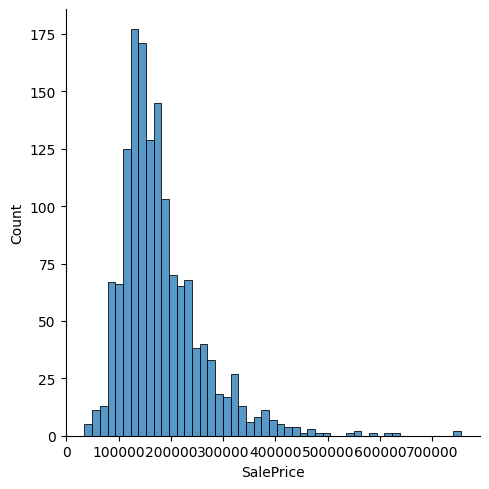

In [11]:
target = 'SalePrice'

print(f"{df[target].skew()=}, {df[target].kurt()=}")
sns.displot(df[target])

df['SalePrice_Log'].skew()=np.float64(0.12133506220520406), df['SalePrice_Log'].kurt()=np.float64(0.8095319958036296)


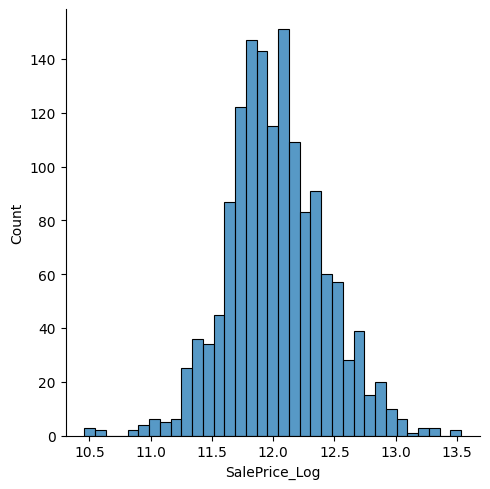

In [12]:
df['SalePrice_Log'] = np.log(df['SalePrice'])
sns.displot(df['SalePrice_Log']);

print(f"{df['SalePrice_Log'].skew()=}, {df['SalePrice_Log'].kurt()=}")

#### Распределение фич

In [13]:
for col in numerical_feats:
    print(
        "{:15}".format(col),
        "Skewness: {:05.2f}".format(df[col].skew()),
        "   ",
        "Kurtosis: {:06.2f}".format(df[col].kurt()),
    )

MSSubClass      Skewness: 01.41     Kurtosis: 001.58
LotFrontage     Skewness: 02.16     Kurtosis: 017.45
LotArea         Skewness: 12.21     Kurtosis: 203.24
OverallQual     Skewness: 00.22     Kurtosis: 000.10
OverallCond     Skewness: 00.69     Kurtosis: 001.11
YearBuilt       Skewness: -0.61     Kurtosis: -00.44
YearRemodAdd    Skewness: -0.50     Kurtosis: -01.27
MasVnrArea      Skewness: 02.67     Kurtosis: 010.08
BsmtFinSF1      Skewness: 01.69     Kurtosis: 011.12
BsmtFinSF2      Skewness: 04.26     Kurtosis: 020.11
BsmtUnfSF       Skewness: 00.92     Kurtosis: 000.47
TotalBsmtSF     Skewness: 01.52     Kurtosis: 013.25
1stFlrSF        Skewness: 01.38     Kurtosis: 005.75
2ndFlrSF        Skewness: 00.81     Kurtosis: -00.55
LowQualFinSF    Skewness: 09.01     Kurtosis: 083.23
GrLivArea       Skewness: 01.37     Kurtosis: 004.90
BsmtFullBath    Skewness: 00.60     Kurtosis: -00.84
BsmtHalfBath    Skewness: 04.10     Kurtosis: 016.40
FullBath        Skewness: 00.04     Kurtosis: 

In [14]:
df.to_csv(f'data/house_prices/train_with_log_target.csv', index=True)

In [15]:
X = df.copy()


y = X['SalePrice_Log']
X.drop(columns=['SalePrice', 'SalePrice_Log'])
X

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice_Log
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,...,None,None,None,0,2,2008,WD,Normal,208500,12.247694
2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,...,None,None,None,0,5,2007,WD,Normal,181500,12.109011
3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,...,None,None,None,0,9,2008,WD,Normal,223500,12.317167
4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,...,None,None,None,0,2,2006,WD,Abnorml,140000,11.849398
5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,...,None,None,None,0,12,2008,WD,Normal,250000,12.429216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,Pave,None,Reg,Lvl,AllPub,Inside,...,None,None,None,0,8,2007,WD,Normal,175000,12.072541
1457,20,RL,85.0,13175,Pave,None,Reg,Lvl,AllPub,Inside,...,None,MnPrv,None,0,2,2010,WD,Normal,210000,12.254863
1458,70,RL,66.0,9042,Pave,None,Reg,Lvl,AllPub,Inside,...,None,GdPrv,Shed,2500,5,2010,WD,Normal,266500,12.493130


In [16]:
df_encoded = pd.get_dummies(df, columns=categorical_feats, dtype=int)
df_encoded

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
Id,,,,,,,,,,,,,,,,,,,,,
1,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,0,0,1,0,0,0,0,1,0
2,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,0,0,0,1,0,0,0,0,1,0
3,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,0,0,1,0,0,0,0,1,0
4,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,0,0,1,1,0,0,0,0,0
5,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,0,0,0,1,0,0,0,0,1,0
1457,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,0,0,0,1,0,0,0,0,1,0
1458,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,0,0,0,1,0,0,0,0,1,0


In [ ]:
from ml_pipeline.regression.pipeline import RegressionPipeline

In [18]:
pipeline = RegressionPipeline()

In [19]:
pipeline.run()

{'model': 'dummy'}
Шаг (0): dummy с {'strategy': 'mean'}
Фолд 1/5 neg_root_mean_squared_error: -0.4332
Фолд 2/5 neg_root_mean_squared_error: -0.3958
Фолд 3/5 neg_root_mean_squared_error: -0.3754
Фолд 4/5 neg_root_mean_squared_error: -0.4210
Фолд 5/5 neg_root_mean_squared_error: -0.3685
-> Лучший фолд: 5, CV neg_root_mean_squared_error: -0.3988, std: 0.0251

{'model': 'logistic_regression', 'params': {'alpha': 1.0}}
Шаг (1): logistic_regression с {'alpha': 1.0, 'solver': 'auto', 'max_iter': 500}
Фолд 1/5 neg_root_mean_squared_error: -0.0935
Фолд 2/5 neg_root_mean_squared_error: -0.0924
Фолд 3/5 neg_root_mean_squared_error: -0.0861
Фолд 4/5 neg_root_mean_squared_error: -0.0860
Фолд 5/5 neg_root_mean_squared_error: -0.0793
-> Лучший фолд: 5, CV neg_root_mean_squared_error: -0.0875, std: 0.0051

